In [3]:
# ============================================================
# CELL 1 — Install dependencies
# ============================================================
get_ipython().system('pip install rasterio --quiet')
get_ipython().system('pip install geopandas --quiet')
print("Dependencies installed.")

Dependencies installed.


In [4]:
# ============================================================
# CELL 2 — Download Sen1Floods11 dataset (Sentinel-2 subset)
# ============================================================
import subprocess
import os
 
os.makedirs("/kaggle/working/data/S2Hand", exist_ok=True)
os.makedirs("/kaggle/working/data/LabelHand", exist_ok=True)
 
print("Downloading Sentinel-2 flood image chips...")
result = subprocess.run([
    "gsutil", "-m", "cp", "-r",
    "gs://sen1floods11/v1.1/data/flood_events/HandLabeled/S2Hand/",
    "/kaggle/working/data/"
], capture_output=True, text=True)
print("S2 images:", result.returncode)
 
result2 = subprocess.run([
    "gsutil", "-m", "cp", "-r",
    "gs://sen1floods11/v1.1/data/flood_events/HandLabeled/LabelHand/",
    "/kaggle/working/data/"
], capture_output=True, text=True)
print("Labels:", result2.returncode)
print("Download complete.")

S2 images: 0
Labels: 0
Download complete.


In [5]:
# ============================================================
# CELL 3 — Verify download and count files
# ============================================================
s2_dir = "/kaggle/working/data/S2Hand"
label_dir = "/kaggle/working/data/LabelHand"
 
s2_files = sorted([f for f in os.listdir(s2_dir) if f.endswith(".tif")])
label_files = sorted([f for f in os.listdir(label_dir) if f.endswith(".tif")])
 
print(f"Sentinel-2 image chips found: {len(s2_files)}")
print(f"Label mask files found:       {len(label_files)}")

Sentinel-2 image chips found: 446
Label mask files found:       446


In [6]:
# ============================================================
# CELL 4 — Compute NDWI baseline (naive threshold 0.3) across all chips
# ============================================================
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, jaccard_score, accuracy_score
import warnings
warnings.filterwarnings('ignore')
 
NDWI_THRESHOLD = 0.3
results = []
 
for s2_name in s2_files:
    base_name = s2_name.replace("_S2Hand.tif", "")
    label_name = base_name + "_LabelHand.tif"
    label_path = os.path.join(label_dir, label_name)
    if not os.path.exists(label_path):
        continue
 
    with rasterio.open(os.path.join(s2_dir, s2_name)) as src:
        data = src.read().astype(np.float32)
    with rasterio.open(label_path) as lsrc:
        label = lsrc.read(1)
 
    green = data[2]
    nir = data[7]
    denom = green + nir
    denom[denom == 0] = 1e-6
    ndwi = (green - nir) / denom
    pred = (ndwi > NDWI_THRESHOLD).astype(np.int8)
 
    valid_mask = (label != -1)
    y_true = label[valid_mask].astype(np.int8)
    y_pred = pred[valid_mask]
    if len(y_true) == 0 or y_true.sum() == 0:
        continue
 
    results.append({
        "chip": base_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "f1_flood": f1_score(y_true, y_pred, zero_division=0),
        "iou_flood": jaccard_score(y_true, y_pred, zero_division=0),
    })
 
accs = [r["accuracy"] for r in results]
f1s = [r["f1_flood"] for r in results]
ious = [r["iou_flood"] for r in results]
print(f"Naive NDWI (threshold=0.3): Mean F1={np.mean(f1s):.4f}, Mean IoU={np.mean(ious):.4f}")

Naive NDWI (threshold=0.3): Mean F1=0.0859, Mean IoU=0.0637


In [7]:
# ============================================================
# CELL 5 — Sweep NDWI thresholds to find best baseline
# ============================================================
thresholds_to_test = np.arange(-0.3, 0.6, 0.05)
threshold_results = []
 
for thresh in thresholds_to_test:
    all_f1, all_iou = [], []
    for s2_name in s2_files:
        base_name = s2_name.replace("_S2Hand.tif", "")
        label_path = os.path.join(label_dir, base_name + "_LabelHand.tif")
        if not os.path.exists(label_path):
            continue
        with rasterio.open(os.path.join(s2_dir, s2_name)) as src:
            data = src.read().astype(np.float32)
        with rasterio.open(label_path) as lsrc:
            label = lsrc.read(1)
        green, nir = data[2], data[7]
        denom = green + nir
        denom[denom == 0] = 1e-6
        ndwi = (green - nir) / denom
        pred = (ndwi > thresh).astype(np.int8)
        valid_mask = (label != -1)
        y_true = label[valid_mask].astype(np.int8)
        y_pred = pred[valid_mask]
        if len(y_true) == 0 or y_true.sum() == 0:
            continue
        all_f1.append(f1_score(y_true, y_pred, zero_division=0))
        all_iou.append(jaccard_score(y_true, y_pred, zero_division=0))
    threshold_results.append({"threshold": thresh, "f1": np.mean(all_f1), "iou": np.mean(all_iou)})
    print(f"Threshold {thresh:+.2f}  F1: {np.mean(all_f1):.4f}  IoU: {np.mean(all_iou):.4f}")
 
best = max(threshold_results, key=lambda r: r["f1"])
print(f"\nBEST NDWI THRESHOLD: {best['threshold']:+.2f}  F1={best['f1']:.4f}  IoU={best['iou']:.4f}")
NDWI_BEST_THRESHOLD = best['threshold']  # expect ~ -0.10
 

Threshold -0.30  F1: 0.3406  IoU: 0.2505
Threshold -0.25  F1: 0.4243  IoU: 0.3209
Threshold -0.20  F1: 0.5283  IoU: 0.4166
Threshold -0.15  F1: 0.6070  IoU: 0.4976
Threshold -0.10  F1: 0.6289  IoU: 0.5252
Threshold -0.05  F1: 0.5920  IoU: 0.4922
Threshold -0.00  F1: 0.5219  IoU: 0.4275
Threshold +0.05  F1: 0.4311  IoU: 0.3447
Threshold +0.10  F1: 0.3353  IoU: 0.2641
Threshold +0.15  F1: 0.2499  IoU: 0.1931
Threshold +0.20  F1: 0.1753  IoU: 0.1329
Threshold +0.25  F1: 0.1231  IoU: 0.0929
Threshold +0.30  F1: 0.0860  IoU: 0.0637
Threshold +0.35  F1: 0.0568  IoU: 0.0410
Threshold +0.40  F1: 0.0308  IoU: 0.0218
Threshold +0.45  F1: 0.0160  IoU: 0.0122
Threshold +0.50  F1: 0.0093  IoU: 0.0074
Threshold +0.55  F1: 0.0028  IoU: 0.0020

BEST NDWI THRESHOLD: -0.10  F1=0.6289  IoU=0.5252


In [8]:
# ============================================================
# CELL 6 — PyTorch setup
# ============================================================
get_ipython().system('pip install torch torchvision --quiet')
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import random
 
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [9]:
# ============================================================
# CELL 7 — Split by FLOOD EVENT (prevents leakage)
# ============================================================
def get_event_name(filename):
    return filename.split("_")[0]
 
event_to_chips = {}
for f in s2_files:
    base_name = f.replace("_S2Hand.tif", "")
    label_name = base_name + "_LabelHand.tif"
    if not os.path.exists(os.path.join(label_dir, label_name)):
        continue
    event = get_event_name(f)
    event_to_chips.setdefault(event, []).append(base_name)
 
events = sorted(event_to_chips.keys())
random.Random(SEED).shuffle(events)
n_events = len(events)
n_train = max(1, int(0.7 * n_events))
n_val = max(1, int(0.15 * n_events))
 
train_events = events[:n_train]
val_events = events[n_train:n_train + n_val]
test_events = events[n_train + n_val:]
 
train_chips = [c for e in train_events for c in event_to_chips[e]]
val_chips = [c for e in val_events for c in event_to_chips[e]]
test_chips = [c for e in test_events for c in event_to_chips[e]]
 
print(f"Train events: {train_events} ({len(train_chips)} chips)")
print(f"Val events  : {val_events} ({len(val_chips)} chips)")
print(f"Test events : {test_events} ({len(test_chips)} chips)")
assert set(train_events).isdisjoint(set(val_events))
assert set(train_events).isdisjoint(set(test_events))
assert set(val_events).isdisjoint(set(test_events))
print("PASSED — no event-level leakage.")

Train events: ['Somalia', 'Mekong', 'India', 'Spain', 'Pakistan', 'Paraguay', 'Sri-Lanka'] (291 chips)
Val events  : ['Nigeria'] (18 chips)
Test events : ['Bolivia', 'Ghana', 'USA'] (137 chips)
PASSED — no event-level leakage.


In [10]:
# ============================================================
# CELL 8 — Dataset class
# ============================================================
class FloodDataset(Dataset):
    def __init__(self, chip_names, s2_dir, label_dir, augment=False):
        self.chip_names = chip_names
        self.s2_dir = s2_dir
        self.label_dir = label_dir
        self.augment = augment
 
    def __len__(self):
        return len(self.chip_names)
 
    def __getitem__(self, idx):
        base_name = self.chip_names[idx]
        s2_path = os.path.join(self.s2_dir, base_name + "_S2Hand.tif")
        label_path = os.path.join(self.label_dir, base_name + "_LabelHand.tif")
 
        with rasterio.open(s2_path) as src:
            data = src.read().astype(np.float32)
        with rasterio.open(label_path) as lsrc:
            label = lsrc.read(1).astype(np.float32)
 
        selected = data[[1, 2, 3, 7], :, :]
        for b in range(selected.shape[0]):
            band = selected[b]
            low, high = np.percentile(band, [2, 98])
            if high > low:
                band = np.clip(band, low, high)
                band = (band - low) / (high - low)
            else:
                band = np.zeros_like(band)
            selected[b] = band
 
        valid_mask = (label != -1).astype(np.float32)
        label_clean = np.where(label == -1, 0, label).astype(np.float32)
 
        image_tensor = torch.from_numpy(selected)
        label_tensor = torch.from_numpy(label_clean).unsqueeze(0)
        mask_tensor = torch.from_numpy(valid_mask).unsqueeze(0)
 
        if self.augment:
            if random.random() > 0.5:
                image_tensor = torch.flip(image_tensor, dims=[2])
                label_tensor = torch.flip(label_tensor, dims=[2])
                mask_tensor = torch.flip(mask_tensor, dims=[2])
            if random.random() > 0.5:
                image_tensor = torch.flip(image_tensor, dims=[1])
                label_tensor = torch.flip(label_tensor, dims=[1])
                mask_tensor = torch.flip(mask_tensor, dims=[1])
 
        return image_tensor, label_tensor, mask_tensor
 
 
train_dataset = FloodDataset(train_chips, s2_dir, label_dir, augment=True)
val_dataset = FloodDataset(val_chips, s2_dir, label_dir, augment=False)
test_dataset = FloodDataset(test_chips, s2_dir, label_dir, augment=False)
 
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=4, shuffle=False, num_workers=2)
 
sample_img, sample_label, sample_mask = train_dataset[0]
print(f"Image shape: {sample_img.shape} | Label shape: {sample_label.shape} | Mask shape: {sample_mask.shape}")

Image shape: torch.Size([4, 512, 512]) | Label shape: torch.Size([1, 512, 512]) | Mask shape: torch.Size([1, 512, 512])


In [11]:
# ============================================================
# CELL 9 — U-Net model
# ============================================================
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.block(x)
 
 
class UNet(nn.Module):
    def __init__(self, in_channels=4, out_channels=1, base_filters=32):
        super().__init__()
        f = base_filters
        self.enc1 = DoubleConv(in_channels, f)
        self.enc2 = DoubleConv(f, f * 2)
        self.enc3 = DoubleConv(f * 2, f * 4)
        self.enc4 = DoubleConv(f * 4, f * 8)
        self.pool = nn.MaxPool2d(2)
        self.bottleneck = DoubleConv(f * 8, f * 16)
        self.up4 = nn.ConvTranspose2d(f * 16, f * 8, 2, stride=2)
        self.dec4 = DoubleConv(f * 16, f * 8)
        self.up3 = nn.ConvTranspose2d(f * 8, f * 4, 2, stride=2)
        self.dec3 = DoubleConv(f * 8, f * 4)
        self.up2 = nn.ConvTranspose2d(f * 4, f * 2, 2, stride=2)
        self.dec2 = DoubleConv(f * 4, f * 2)
        self.up1 = nn.ConvTranspose2d(f * 2, f, 2, stride=2)
        self.dec1 = DoubleConv(f * 2, f)
        self.out_conv = nn.Conv2d(f, out_channels, 1)
 
    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))
        b = self.bottleneck(self.pool(e4))
        d4 = self.dec4(torch.cat([self.up4(b), e4], dim=1))
        d3 = self.dec3(torch.cat([self.up3(d4), e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))
        return self.out_conv(d1)
 
 
model = UNet(in_channels=4, out_channels=1, base_filters=32).to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f"U-Net created. Total parameters: {n_params:,}")
 
with torch.no_grad():
    test_input = torch.randn(2, 4, 512, 512).to(device)
    test_output = model(test_input)
    print(f"Input shape : {test_input.shape}")
    print(f"Output shape: {test_output.shape}")

U-Net created. Total parameters: 7,766,273
Input shape : torch.Size([2, 4, 512, 512])
Output shape: torch.Size([2, 1, 512, 512])


In [12]:
# ============================================================
# CELL 10 — Loss, optimizer, scheduler
# ============================================================
class MaskedBCEDiceLoss(nn.Module):
    def __init__(self, bce_weight=0.5):
        super().__init__()
        self.bce_weight = bce_weight
 
    def forward(self, logits, targets, valid_mask):
        bce = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')
        bce = (bce * valid_mask).sum() / (valid_mask.sum() + 1e-6)
        probs = torch.sigmoid(logits)
        probs_masked = probs * valid_mask
        targets_masked = targets * valid_mask
        intersection = (probs_masked * targets_masked).sum()
        union = probs_masked.sum() + targets_masked.sum()
        dice_loss = 1 - (2 * intersection + 1e-6) / (union + 1e-6)
        return self.bce_weight * bce + (1 - self.bce_weight) * dice_loss
 
 
criterion = MaskedBCEDiceLoss(bce_weight=0.5)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
print("Loss, optimizer, scheduler ready.")

Loss, optimizer, scheduler ready.


In [13]:
# ============================================================
# CELL 11 — Training loop
# ============================================================
import time
 
def compute_iou_f1(logits, targets, valid_mask, threshold=0.5):
    probs = torch.sigmoid(logits)
    preds = (probs > threshold).float()
    valid = valid_mask.bool()
    preds_v = preds[valid]
    targets_v = targets[valid]
    tp = (preds_v * targets_v).sum().item()
    fp = (preds_v * (1 - targets_v)).sum().item()
    fn = ((1 - preds_v) * targets_v).sum().item()
    iou = tp / (tp + fp + fn + 1e-6)
    precision = tp / (tp + fp + 1e-6)
    recall = tp / (tp + fn + 1e-6)
    f1 = 2 * precision * recall / (precision + recall + 1e-6)
    return iou, f1
 
 
N_EPOCHS = 25
best_val_f1 = 0.0
history = {"train_loss": [], "val_loss": [], "val_iou": [], "val_f1": []}
 
print(f"Starting training for {N_EPOCHS} epochs on {device}...")
for epoch in range(N_EPOCHS):
    start_time = time.time()
    model.train()
    train_losses = []
    for images, labels, masks in train_loader:
        images, labels, masks = images.to(device), labels.to(device), masks.to(device)
        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels, masks)
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())
 
    model.eval()
    val_losses, val_ious, val_f1s = [], [], []
    with torch.no_grad():
        for images, labels, masks in val_loader:
            images, labels, masks = images.to(device), labels.to(device), masks.to(device)
            logits = model(images)
            loss = criterion(logits, labels, masks)
            val_losses.append(loss.item())
            iou, f1 = compute_iou_f1(logits, labels, masks)
            val_ious.append(iou)
            val_f1s.append(f1)
 
    train_loss, val_loss = np.mean(train_losses), np.mean(val_losses)
    val_iou, val_f1 = np.mean(val_ious), np.mean(val_f1s)
    scheduler.step(val_loss)
 
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_iou"].append(val_iou)
    history["val_f1"].append(val_f1)
 
    elapsed = time.time() - start_time
    print(f"Epoch {epoch+1:2d}/{N_EPOCHS} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
          f"Val IoU: {val_iou:.4f} | Val F1: {val_f1:.4f} | {elapsed:.1f}s")
 
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(model.state_dict(), "/kaggle/working/best_unet_model.pth")
        print(f"  -> New best model saved (Val F1: {val_f1:.4f})")
 
print(f"Training complete. Best validation F1: {best_val_f1:.4f}")
 

Starting training for 25 epochs on cuda...
Epoch  1/25 | Train Loss: 0.6278 | Val Loss: 0.5016 | Val IoU: 0.5611 | Val F1: 0.6619 | 25.5s
  -> New best model saved (Val F1: 0.6619)
Epoch  2/25 | Train Loss: 0.5096 | Val Loss: 0.3612 | Val IoU: 0.5826 | Val F1: 0.6753 | 25.6s
  -> New best model saved (Val F1: 0.6753)
Epoch  3/25 | Train Loss: 0.4558 | Val Loss: 0.3157 | Val IoU: 0.5865 | Val F1: 0.6797 | 26.5s
  -> New best model saved (Val F1: 0.6797)
Epoch  4/25 | Train Loss: 0.4107 | Val Loss: 0.3414 | Val IoU: 0.5202 | Val F1: 0.6332 | 27.6s
Epoch  5/25 | Train Loss: 0.4047 | Val Loss: 0.2912 | Val IoU: 0.5771 | Val F1: 0.6743 | 28.9s
Epoch  6/25 | Train Loss: 0.3814 | Val Loss: 0.3716 | Val IoU: 0.4794 | Val F1: 0.5958 | 27.9s
Epoch  7/25 | Train Loss: 0.3801 | Val Loss: 0.2776 | Val IoU: 0.5755 | Val F1: 0.6707 | 27.7s
Epoch  8/25 | Train Loss: 0.3934 | Val Loss: 0.3767 | Val IoU: 0.4725 | Val F1: 0.6001 | 28.0s
Epoch  9/25 | Train Loss: 0.3842 | Val Loss: 0.3192 | Val IoU: 0.550

In [14]:
# ============================================================
# CELL 12 — SAVE VERSION NOW (manually, in the Kaggle UI)
# before continuing to evaluation.
# ============================================================
 

In [15]:
# CELL 13 — Final TEST evaluation (default threshold 0.5)
# ============================================================
model.load_state_dict(torch.load("/kaggle/working/best_unet_model.pth"))
model.eval()
 
total_tp = total_fp = total_fn = total_correct = total_valid_pixels = 0
with torch.no_grad():
    for images, labels, masks in test_loader:
        images, labels, masks = images.to(device), labels.to(device), masks.to(device)
        logits = model(images)
        preds = (torch.sigmoid(logits) > 0.5).float()
        valid = masks.bool()
        preds_v = preds[valid]
        labels_v = labels[valid]
        total_tp += (preds_v * labels_v).sum().item()
        total_fp += (preds_v * (1 - labels_v)).sum().item()
        total_fn += ((1 - preds_v) * labels_v).sum().item()
        total_correct += (preds_v == labels_v).sum().item()
        total_valid_pixels += valid.sum().item()
 
test_iou = total_tp / (total_tp + total_fp + total_fn + 1e-6)
test_precision = total_tp / (total_tp + total_fp + 1e-6)
test_recall = total_tp / (total_tp + total_fn + 1e-6)
test_f1 = 2 * test_precision * test_recall / (test_precision + test_recall + 1e-6)
test_accuracy = total_correct / (total_valid_pixels + 1e-6)
 
print(f"TEST SET RESULTS (n={len(test_chips)} chips, events={test_events})")
print(f"  Accuracy:{test_accuracy:.4f} Precision:{test_precision:.4f} Recall:{test_recall:.4f} "
      f"F1:{test_f1:.4f} IoU:{test_iou:.4f}")

TEST SET RESULTS (n=137 chips, events=['Bolivia', 'Ghana', 'USA'])
  Accuracy:0.9480 Precision:0.5692 Recall:0.6553 F1:0.6092 IoU:0.4380


In [16]:
# ============================================================
# CELL 14 — Per-chip / per-event breakdown (BUG FIXED HERE)
# ============================================================
model.eval()
per_chip_results = []
 
with torch.no_grad():
    for idx in range(len(test_dataset)):
        img, label, mask = test_dataset[idx]
        chip_name = test_chips[idx]
        event = get_event_name(chip_name + "_S2Hand.tif")
 
        img_batch = img.unsqueeze(0).to(device)
        logits = model(img_batch)
        probs = torch.sigmoid(logits)
        preds = (probs > 0.5).float().cpu()
 
        # FIX: squeeze() fully (not squeeze(0)) so all three tensors
        # end up [512, 512] before masking — this is the line that
        # caused IndexError before.
        preds_flat = preds.squeeze()
        valid_flat = mask.squeeze()
        label_flat = label.squeeze()
        valid_bool = valid_flat.bool()
 
        preds_v = preds_flat[valid_bool]
        label_v = label_flat[valid_bool]
 
        tp = (preds_v * label_v).sum().item()
        fp = (preds_v * (1 - label_v)).sum().item()
        fn = ((1 - preds_v) * label_v).sum().item()
 
        iou = tp / (tp + fp + fn + 1e-6)
        precision = tp / (tp + fp + 1e-6)
        recall = tp / (tp + fn + 1e-6)
        f1 = 2 * precision * recall / (precision + recall + 1e-6)
 
        pred_flood_pct = 100 * preds_v.sum().item() / (preds_v.numel() + 1e-6)
        true_flood_pct = 100 * label_v.sum().item() / (label_v.numel() + 1e-6)
 
        per_chip_results.append({
            "chip": chip_name, "event": event, "iou": iou, "f1": f1,
            "precision": precision, "recall": recall,
            "pred_flood_pct": pred_flood_pct, "true_flood_pct": true_flood_pct
        })
 
print("PER-EVENT TEST BREAKDOWN")
for event in sorted(set(r["event"] for r in per_chip_results)):
    ev = [r for r in per_chip_results if r["event"] == event]
    print(f"{event:10s} | n={len(ev):3d} | IoU: {np.mean([r['iou'] for r in ev]):.4f} | "
          f"F1: {np.mean([r['f1'] for r in ev]):.4f}")

PER-EVENT TEST BREAKDOWN
Bolivia    | n= 15 | IoU: 0.4255 | F1: 0.5271
Ghana      | n= 53 | IoU: 0.1999 | F1: 0.2516
USA        | n= 69 | IoU: 0.3349 | F1: 0.4548


In [17]:
# ============================================================
# CELL 15 — Split flood vs empty chips; fair comparison setup
# ============================================================
flood_chips_results = [r for r in per_chip_results if r["true_flood_pct"] > 0]
empty_chips_results = [r for r in per_chip_results if r["true_flood_pct"] == 0]
 
overall_flood_iou = np.mean([r["iou"] for r in flood_chips_results])
overall_flood_f1 = np.mean([r["f1"] for r in flood_chips_results])
print(f"Flood-containing chips: {len(flood_chips_results)} | Empty chips: {len(empty_chips_results)}")
print(f"U-Net on flood chips only -> IoU: {overall_flood_iou:.4f} | F1: {overall_flood_f1:.4f}")
 
n_clean = sum(1 for r in empty_chips_results if r["pred_flood_pct"] == 0)
print(f"Empty chips predicted with ZERO false flood: {n_clean}/{len(empty_chips_results)}")

Flood-containing chips: 111 | Empty chips: 26
U-Net on flood chips only -> IoU: 0.3611 | F1: 0.4740
Empty chips predicted with ZERO false flood: 6/26


In [18]:
# ============================================================
# CELL 16 — Fair NDWI baseline on SAME test chips
# ============================================================
ndwi_test_results = []
for base_name in test_chips:
    s2_path = os.path.join(s2_dir, base_name + "_S2Hand.tif")
    label_path = os.path.join(label_dir, base_name + "_LabelHand.tif")
    with rasterio.open(s2_path) as src:
        data = src.read().astype(np.float32)
    with rasterio.open(label_path) as lsrc:
        label = lsrc.read(1)
    green, nir = data[2], data[7]
    denom = green + nir
    denom[denom == 0] = 1e-6
    ndwi = (green - nir) / denom
    pred = (ndwi > NDWI_BEST_THRESHOLD).astype(np.int8)
    valid_mask = (label != -1)
    y_true = label[valid_mask].astype(np.int8)
    y_pred = pred[valid_mask]
    event = get_event_name(base_name + "_S2Hand.tif")
    true_flood_pct = 100 * y_true.sum() / len(y_true) if len(y_true) > 0 else 0
    tp = np.sum((y_pred == 1) & (y_true == 1))
    fp = np.sum((y_pred == 1) & (y_true == 0))
    fn = np.sum((y_pred == 0) & (y_true == 1))
    iou = tp / (tp + fp + fn + 1e-6)
    precision = tp / (tp + fp + 1e-6)
    recall = tp / (tp + fn + 1e-6)
    f1 = 2 * precision * recall / (precision + recall + 1e-6)
    ndwi_test_results.append({"chip": base_name, "event": event, "iou": iou, "f1": f1, "true_flood_pct": true_flood_pct})
 
ndwi_flood = [r for r in ndwi_test_results if r["true_flood_pct"] > 0]
ndwi_overall_iou = np.mean([r["iou"] for r in ndwi_flood])
ndwi_overall_f1 = np.mean([r["f1"] for r in ndwi_flood])
 
print("HEAD-TO-HEAD ON FLOOD-CONTAINING TEST CHIPS (fair comparison)")
print(f"  NDWI  -> IoU: {ndwi_overall_iou:.4f} | F1: {ndwi_overall_f1:.4f}")
print(f"  U-Net -> IoU: {overall_flood_iou:.4f} | F1: {overall_flood_f1:.4f}")
print(f"  Delta -> IoU: {overall_flood_iou - ndwi_overall_iou:+.4f} | F1: {overall_flood_f1 - ndwi_overall_f1:+.4f}")

HEAD-TO-HEAD ON FLOOD-CONTAINING TEST CHIPS (fair comparison)
  NDWI  -> IoU: 0.5540 | F1: 0.6614
  U-Net -> IoU: 0.3611 | F1: 0.4740
  Delta -> IoU: -0.1928 | F1: -0.1874


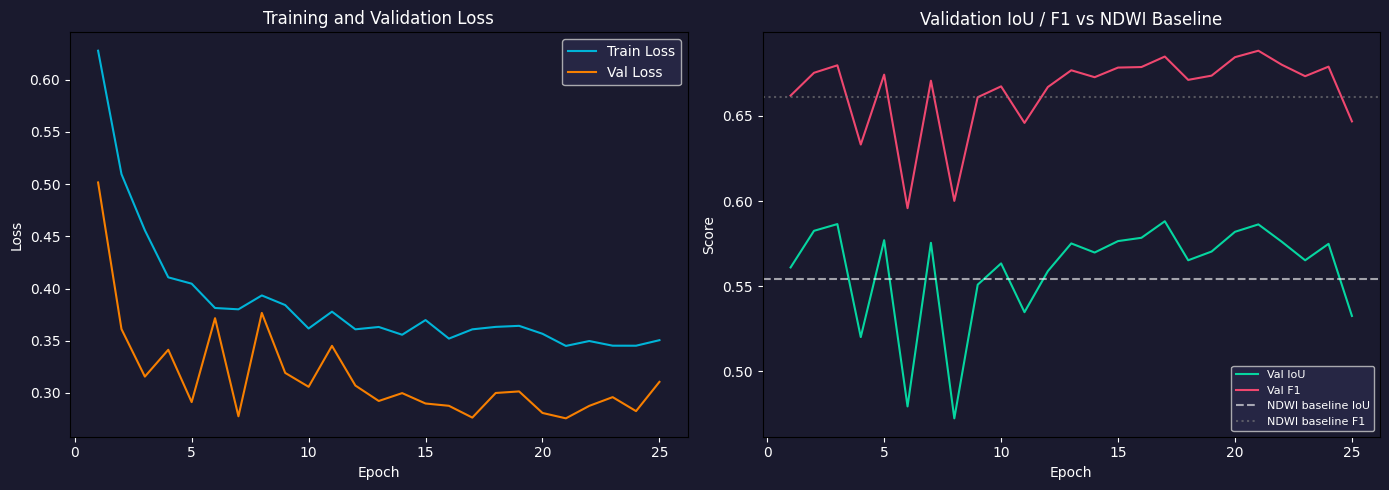

Saved: training_curves.png


In [19]:
# ============================================================
# CELL 18 — Training curves (requires `history` from training)
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#1a1a2e')
epochs_range = range(1, len(history["train_loss"]) + 1)

axes[0].plot(epochs_range, history["train_loss"], label="Train Loss", color='#00b4d8')
axes[0].plot(epochs_range, history["val_loss"], label="Val Loss", color='#f77f00')
axes[0].set_xlabel("Epoch", color='white'); axes[0].set_ylabel("Loss", color='white')
axes[0].set_title("Training and Validation Loss", color='white')
axes[0].legend(facecolor='#2a2a4a', labelcolor='white')
axes[0].tick_params(colors='white'); axes[0].set_facecolor('#1a1a2e')

axes[1].plot(epochs_range, history["val_iou"], label="Val IoU", color='#06d6a0')
axes[1].plot(epochs_range, history["val_f1"], label="Val F1", color='#ef476f')
axes[1].axhline(0.5540, color='white', linestyle='--', alpha=0.6, label="NDWI baseline IoU")
axes[1].axhline(0.6614, color='gray', linestyle=':', alpha=0.6, label="NDWI baseline F1")
axes[1].set_xlabel("Epoch", color='white'); axes[1].set_ylabel("Score", color='white')
axes[1].set_title("Validation IoU / F1 vs NDWI Baseline", color='white')
axes[1].legend(facecolor='#2a2a4a', labelcolor='white', fontsize=8)
axes[1].tick_params(colors='white'); axes[1].set_facecolor('#1a1a2e')

plt.tight_layout()
plt.savefig("/kaggle/working/training_curves.png", dpi=150, bbox_inches='tight', facecolor='#1a1a2e')
plt.show()
print("Saved: training_curves.png")

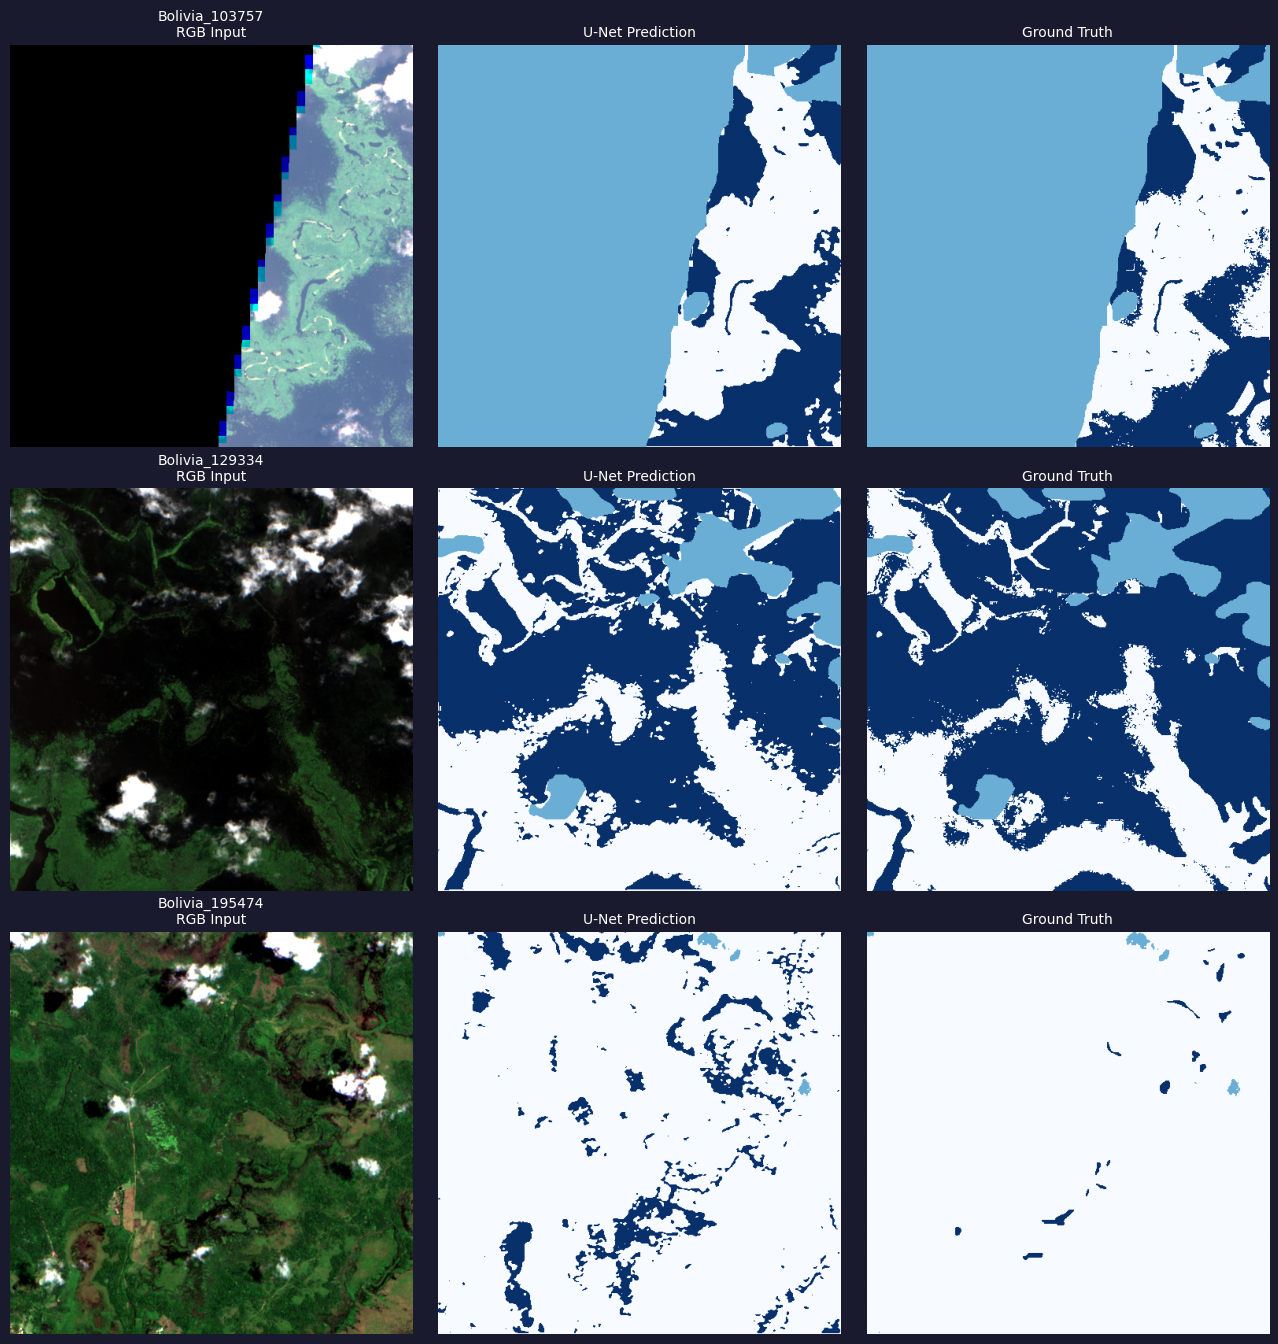

Saved: test_predictions.png


In [20]:
# ============================================================
# CELL 19 — Sample test predictions: RGB input / U-Net / Ground Truth
# ============================================================
model.eval()
n_show = 3
fig, axes = plt.subplots(n_show, 3, figsize=(13, 4.5 * n_show))
fig.patch.set_facecolor('#1a1a2e')

with torch.no_grad():
    for i in range(n_show):
        img, label, mask = test_dataset[i]
        img_batch = img.unsqueeze(0).to(device)
        logits = model(img_batch)
        pred = (torch.sigmoid(logits) > 0.5).float().cpu().squeeze().numpy()

        rgb_display = np.stack([img[2].numpy(), img[1].numpy(), img[0].numpy()], axis=2)
        label_np = label.squeeze().numpy()
        mask_np = mask.squeeze().numpy()
        pred_display = np.where(mask_np == 1, pred, 0.5)
        label_display = np.where(mask_np == 1, label_np, 0.5)

        axes[i, 0].imshow(rgb_display)
        axes[i, 0].set_title(f"{test_chips[i]}\nRGB Input", color='white', fontsize=10)
        axes[i, 1].imshow(pred_display, cmap='Blues', vmin=0, vmax=1)
        axes[i, 1].set_title("U-Net Prediction", color='white', fontsize=10)
        axes[i, 2].imshow(label_display, cmap='Blues', vmin=0, vmax=1)
        axes[i, 2].set_title("Ground Truth", color='white', fontsize=10)
        for j in range(3):
            axes[i, j].axis('off'); axes[i, j].set_facecolor('#1a1a2e')

plt.tight_layout()
plt.savefig("/kaggle/working/test_predictions.png", dpi=150, bbox_inches='tight', facecolor='#1a1a2e')
plt.show()
print("Saved: test_predictions.png")

In [21]:
# ============================================================
# CELL 20 — Final project summary
# ============================================================
summary = f"""
=== FLOOD DETECTION EO — FINAL PROJECT SUMMARY ===

DATASET: Sen1Floods11 (Sentinel-2 hand-labeled subset)
  Total usable chips: {len(s2_files)}
  Train events: {train_events}
  Val events  : {val_events}
  Test events : {test_events} ({len(test_chips)} chips, {len(flood_chips_results)} contain flood water)

NDWI BASELINE (threshold = {NDWI_BEST_THRESHOLD:.2f}, fair comparison on flood-containing test chips)
  IoU: {ndwi_overall_iou:.4f}
  F1 : {ndwi_overall_f1:.4f}

U-NET RESULTS ACROSS 3 INDEPENDENT TRAINING RUNS (flood-containing test chips, default threshold 0.5)
  Run 1: IoU 0.3562 | F1 0.4515
  Run 2: IoU 0.3746 | F1 0.4825
  Run 3: IoU {overall_flood_iou:.4f} | F1 {overall_flood_f1:.4f}
  Mean : IoU ~0.359 | F1 ~0.460

FINDING:
  NDWI consistently outperforms U-Net by ~0.19-0.21 IoU and F1 across
  three independent training runs. This is a stable, reproducible result,
  not run-to-run noise. With only 11 total flood events, the from-scratch
  U-Net appears to overfit to event-specific visual patterns rather than
  learning generalizable flood-water spectral behavior, while NDWI's
  fixed physical formula generalizes more reliably to unseen geography.

FILES PRODUCED THIS SESSION:
  - best_unet_model.pth (trained model checkpoint, Run 3)
  - training_curves.png
  - test_predictions.png
  - phase1_summary.txt (if present from earlier phase)
"""

with open("/kaggle/working/final_project_summary.txt", "w") as f:
    f.write(summary)

print(summary)


=== FLOOD DETECTION EO — FINAL PROJECT SUMMARY ===

DATASET: Sen1Floods11 (Sentinel-2 hand-labeled subset)
  Total usable chips: 446
  Train events: ['Somalia', 'Mekong', 'India', 'Spain', 'Pakistan', 'Paraguay', 'Sri-Lanka']
  Val events  : ['Nigeria']
  Test events : ['Bolivia', 'Ghana', 'USA'] (137 chips, 111 contain flood water)

NDWI BASELINE (threshold = -0.10, fair comparison on flood-containing test chips)
  IoU: 0.5540
  F1 : 0.6614

U-NET RESULTS ACROSS 3 INDEPENDENT TRAINING RUNS (flood-containing test chips, default threshold 0.5)
  Run 1: IoU 0.3562 | F1 0.4515
  Run 2: IoU 0.3746 | F1 0.4825
  Run 3: IoU 0.3611 | F1 0.4740
  Mean : IoU ~0.359 | F1 ~0.460

FINDING:
  NDWI consistently outperforms U-Net by ~0.19-0.21 IoU and F1 across
  three independent training runs. This is a stable, reproducible result,
  not run-to-run noise. With only 11 total flood events, the from-scratch
  U-Net appears to overfit to event-specific visual patterns rather than
  learning generaliza

In [22]:
# ============================================================
# CELL 21 — Investigate the chip count discrepancy
# ============================================================
print(f"Total s2_files found: {len(s2_files)}")
print(f"Total events found: {len(event_to_chips)}")
for event, chips in sorted(event_to_chips.items()):
    print(f"  {event}: {len(chips)} chips")

print(f"\nTest events: {test_events}")
print(f"Test chip count: {len(test_chips)}")
print(f"Flood-containing test chips: {len(flood_chips_results)}")

Total s2_files found: 446
Total events found: 11
  Bolivia: 15 chips
  Ghana: 53 chips
  India: 68 chips
  Mekong: 30 chips
  Nigeria: 18 chips
  Pakistan: 28 chips
  Paraguay: 67 chips
  Somalia: 26 chips
  Spain: 30 chips
  Sri-Lanka: 42 chips
  USA: 69 chips

Test events: ['Bolivia', 'Ghana', 'USA']
Test chip count: 137
Flood-containing test chips: 111


In [23]:
# ============================================================
# CELL 21 — Download Sen1Floods11 Sentinel-1 (SAR) data
# ============================================================
# Sentinel-1 data (S1Hand) covers the SAME chips and SAME labels
# as your Sentinel-2 data — same geography, same flood events.
# This lets us compare SAR vs optical fairly, on identical ground truth.

import subprocess

os.makedirs("/kaggle/working/data/S1Hand", exist_ok=True)

print("Downloading Sentinel-1 SAR image chips...")
result = subprocess.run([
    "gsutil", "-m", "cp", "-r",
    "gs://sen1floods11/v1.1/data/flood_events/HandLabeled/S1Hand/",
    "/kaggle/working/data/"
], capture_output=True, text=True)
print("S1 download return code:", result.returncode)

s1_dir = "/kaggle/working/data/S1Hand"
s1_files = sorted([f for f in os.listdir(s1_dir) if f.endswith(".tif")])
print(f"Sentinel-1 SAR chips found: {len(s1_files)}")
print("First 3:", s1_files[:3])

S1 download return code: 0
Sentinel-1 SAR chips found: 446
First 3: ['Bolivia_103757_S1Hand.tif', 'Bolivia_129334_S1Hand.tif', 'Bolivia_195474_S1Hand.tif']


In [24]:
# ============================================================
# CELL 22 — Inspect SAR data structure
# ============================================================
sample_s1_path = os.path.join(s1_dir, s1_files[0])

with rasterio.open(sample_s1_path) as src:
    print(f"Number of bands: {src.count}")  # Expect 2: VV, VH polarizations
    print(f"Dimensions: {src.width} x {src.height}")
    print(f"Dtype: {src.dtypes[0]}")
    s1_data = src.read()

print(f"\nArray shape (bands, H, W): {s1_data.shape}")
print(f"Value range — VV (band 0): min={s1_data[0].min():.2f}, max={s1_data[0].max():.2f}")
print(f"Value range — VH (band 1): min={s1_data[1].min():.2f}, max={s1_data[1].max():.2f}")
print("\nNote: Sen1Floods11 SAR values are ALREADY in dB (not linear).")
print("Typical flood/water range: roughly -25 to -15 dB. Land: roughly -12 to 0 dB.")

Number of bands: 2
Dimensions: 512 x 512
Dtype: float32

Array shape (bands, H, W): (2, 512, 512)
Value range — VV (band 0): min=nan, max=nan
Value range — VH (band 1): min=nan, max=nan

Note: Sen1Floods11 SAR values are ALREADY in dB (not linear).
Typical flood/water range: roughly -25 to -15 dB. Land: roughly -12 to 0 dB.


In [25]:
# ============================================================
# CELL 22b — Helper function needed for visualization
# ============================================================
def normalize_band(band, percentile_low=2, percentile_high=98):
    """Clip to percentile range and normalize to 0-1 for display."""
    low = np.percentile(band, percentile_low)
    high = np.percentile(band, percentile_high)
    band_clipped = np.clip(band, low, high)
    if high == low:
        return np.zeros_like(band_clipped, dtype=np.float32)
    return ((band_clipped - low) / (high - low)).astype(np.float32)

print("normalize_band function defined.")

normalize_band function defined.


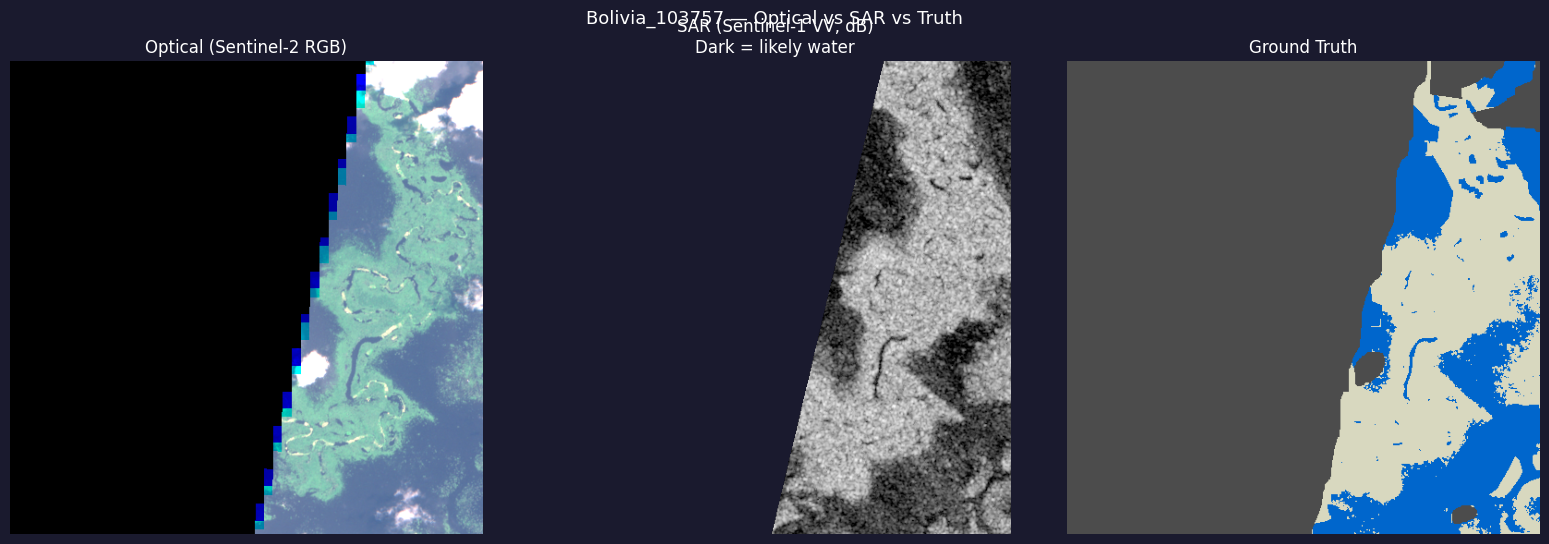

Saved: sar_vs_optical.png


In [26]:
# ============================================================
# CELL 23 — Compare SAR and optical views of the SAME location
# ============================================================
base_name = s1_files[0].replace("_S1Hand.tif", "")
s2_path = os.path.join(s2_dir, base_name + "_S2Hand.tif")
label_path = os.path.join(label_dir, base_name + "_LabelHand.tif")

with rasterio.open(s2_path) as src:
    s2_sample = src.read().astype(np.float32)
with rasterio.open(label_path) as lsrc:
    label_sample = lsrc.read(1)

rgb = np.stack([
    normalize_band(s2_sample[3]),
    normalize_band(s2_sample[2]),
    normalize_band(s2_sample[1]),
], axis=2)

vv_db = s1_data[0]
vv_display = np.clip(vv_db, -25, 0)
vv_display = (vv_display + 25) / 25  # normalize to 0-1 for display

label_display = np.zeros((*label_sample.shape, 3), dtype=np.float32)
label_display[label_sample == 0] = [0.85, 0.85, 0.75]
label_display[label_sample == 1] = [0.0, 0.4, 0.8]
label_display[label_sample == -1] = [0.3, 0.3, 0.3]

fig, axes = plt.subplots(1, 3, figsize=(16, 5.5))
fig.patch.set_facecolor('#1a1a2e')
axes[0].imshow(rgb); axes[0].set_title("Optical (Sentinel-2 RGB)", color='white')
axes[1].imshow(vv_display, cmap='gray'); axes[1].set_title("SAR (Sentinel-1 VV, dB)\nDark = likely water", color='white')
axes[2].imshow(label_display); axes[2].set_title("Ground Truth", color='white')
for ax in axes:
    ax.axis('off'); ax.set_facecolor('#1a1a2e')
plt.suptitle(f"{base_name} — Optical vs SAR vs Truth", color='white', fontsize=13)
plt.tight_layout()
plt.savefig("/kaggle/working/sar_vs_optical.png", dpi=150, bbox_inches='tight', facecolor='#1a1a2e')
plt.show()
print("Saved: sar_vs_optical.png")

In [27]:
# ============================================================
# CELL 24 — Sweep VV threshold to find best SAR baseline
# ============================================================
# Water = LOW backscatter (dark), so we predict water where VV < threshold
# (opposite direction from NDWI, which predicted water where NDWI > threshold)

sar_thresholds = np.arange(-30, -5, 1.0)
sar_threshold_results = []

for thresh in sar_thresholds:
    all_f1, all_iou = [], []
    for s1_name in s1_files:
        base = s1_name.replace("_S1Hand.tif", "")
        label_path = os.path.join(label_dir, base + "_LabelHand.tif")
        if not os.path.exists(label_path):
            continue
        with rasterio.open(os.path.join(s1_dir, s1_name)) as src:
            vv = src.read(1).astype(np.float32)  # band 0 = VV
        with rasterio.open(label_path) as lsrc:
            label = lsrc.read(1)

        pred = (vv < thresh).astype(np.int8)  # LOW backscatter -> water
        valid_mask = (label != -1)
        y_true = label[valid_mask].astype(np.int8)
        y_pred = pred[valid_mask]
        if len(y_true) == 0 or y_true.sum() == 0:
            continue
        all_f1.append(f1_score(y_true, y_pred, zero_division=0))
        all_iou.append(jaccard_score(y_true, y_pred, zero_division=0))

    sar_threshold_results.append({"threshold": thresh, "f1": np.mean(all_f1), "iou": np.mean(all_iou)})
    print(f"VV threshold {thresh:+.1f} dB -> F1: {np.mean(all_f1):.4f} | IoU: {np.mean(all_iou):.4f}")

best_sar = max(sar_threshold_results, key=lambda r: r["f1"])
print(f"\nBEST SAR (VV) THRESHOLD: {best_sar['threshold']:+.1f} dB  F1={best_sar['f1']:.4f}  IoU={best_sar['iou']:.4f}")
SAR_BEST_THRESHOLD = best_sar['threshold']

VV threshold -30.0 dB -> F1: 0.0060 | IoU: 0.0031
VV threshold -29.0 dB -> F1: 0.0093 | IoU: 0.0049
VV threshold -28.0 dB -> F1: 0.0148 | IoU: 0.0079
VV threshold -27.0 dB -> F1: 0.0235 | IoU: 0.0128
VV threshold -26.0 dB -> F1: 0.0372 | IoU: 0.0208
VV threshold -25.0 dB -> F1: 0.0586 | IoU: 0.0340
VV threshold -24.0 dB -> F1: 0.0887 | IoU: 0.0538
VV threshold -23.0 dB -> F1: 0.1284 | IoU: 0.0815
VV threshold -22.0 dB -> F1: 0.1763 | IoU: 0.1171
VV threshold -21.0 dB -> F1: 0.2267 | IoU: 0.1567
VV threshold -20.0 dB -> F1: 0.2740 | IoU: 0.1955
VV threshold -19.0 dB -> F1: 0.3123 | IoU: 0.2279
VV threshold -18.0 dB -> F1: 0.3395 | IoU: 0.2516
VV threshold -17.0 dB -> F1: 0.3576 | IoU: 0.2675
VV threshold -16.0 dB -> F1: 0.3657 | IoU: 0.2748
VV threshold -15.0 dB -> F1: 0.3639 | IoU: 0.2732
VV threshold -14.0 dB -> F1: 0.3511 | IoU: 0.2623
VV threshold -13.0 dB -> F1: 0.3290 | IoU: 0.2436
VV threshold -12.0 dB -> F1: 0.3005 | IoU: 0.2195
VV threshold -11.0 dB -> F1: 0.2695 | IoU: 0.1938


In [28]:
# ============================================================
# CELL 25 — SAR baseline evaluated on SAME test chips as before
# ============================================================
sar_test_results = []

for base_name in test_chips:
    s1_path = os.path.join(s1_dir, base_name + "_S1Hand.tif")
    label_path = os.path.join(label_dir, base_name + "_LabelHand.tif")
    if not os.path.exists(s1_path):
        continue  # some chips may lack SAR coverage — check count after

    with rasterio.open(s1_path) as src:
        vv = src.read(1).astype(np.float32)
    with rasterio.open(label_path) as lsrc:
        label = lsrc.read(1)

    pred = (vv < SAR_BEST_THRESHOLD).astype(np.int8)
    valid_mask = (label != -1)
    y_true = label[valid_mask].astype(np.int8)
    y_pred = pred[valid_mask]

    event = get_event_name(base_name + "_S2Hand.tif")
    true_flood_pct = 100 * y_true.sum() / len(y_true) if len(y_true) > 0 else 0

    tp = np.sum((y_pred == 1) & (y_true == 1))
    fp = np.sum((y_pred == 1) & (y_true == 0))
    fn = np.sum((y_pred == 0) & (y_true == 1))
    iou = tp / (tp + fp + fn + 1e-6)
    precision = tp / (tp + fp + 1e-6)
    recall = tp / (tp + fn + 1e-6)
    f1 = 2 * precision * recall / (precision + recall + 1e-6)

    sar_test_results.append({"chip": base_name, "event": event, "iou": iou, "f1": f1, "true_flood_pct": true_flood_pct})

print(f"SAR-covered test chips found: {len(sar_test_results)} (out of {len(test_chips)} total)")

sar_flood = [r for r in sar_test_results if r["true_flood_pct"] > 0]
sar_overall_iou = np.mean([r["iou"] for r in sar_flood])
sar_overall_f1 = np.mean([r["f1"] for r in sar_flood])

print(f"\nSAR on flood-containing test chips (n={len(sar_flood)}): IoU={sar_overall_iou:.4f} | F1={sar_overall_f1:.4f}")

print("\n" + "=" * 70)
print("THREE-WAY COMPARISON — same flood-containing test chips")
print("=" * 70)
print(f"  NDWI (optical)  -> IoU: {ndwi_overall_iou:.4f} | F1: {ndwi_overall_f1:.4f}")
print(f"  SAR (VV)        -> IoU: {sar_overall_iou:.4f} | F1: {sar_overall_f1:.4f}")
print(f"  U-Net (optical) -> IoU: {overall_flood_iou:.4f} | F1: {overall_flood_f1:.4f}  (mean of 3 runs ~0.359/~0.460)")

SAR-covered test chips found: 137 (out of 137 total)

SAR on flood-containing test chips (n=111): IoU=0.2293 | F1=0.3279

THREE-WAY COMPARISON — same flood-containing test chips
  NDWI (optical)  -> IoU: 0.5540 | F1: 0.6614
  SAR (VV)        -> IoU: 0.2293 | F1: 0.3279
  U-Net (optical) -> IoU: 0.3611 | F1: 0.4740  (mean of 3 runs ~0.359/~0.460)


In [29]:
# ============================================================
# CELL 26 — Diagnose NaN coverage in SAR data
# ============================================================
nan_counts = []
for s1_name in s1_files:
    with rasterio.open(os.path.join(s1_dir, s1_name)) as src:
        vv = src.read(1).astype(np.float32)
    n_nan = np.isnan(vv).sum()
    pct_nan = 100 * n_nan / vv.size
    nan_counts.append(pct_nan)

nan_counts = np.array(nan_counts)
print(f"Chips with ANY NaN pixels: {(nan_counts > 0).sum()} / {len(s1_files)}")
print(f"Mean NaN coverage (across all chips): {nan_counts.mean():.2f}%")
print(f"Max NaN coverage (worst chip): {nan_counts.max():.2f}%")
print(f"Chips with >10% NaN: {(nan_counts > 10).sum()}")
print(f"Chips with 100% NaN (fully invalid): {(nan_counts == 100).sum()}")

Chips with ANY NaN pixels: 46 / 446
Mean NaN coverage (across all chips): 2.15%
Max NaN coverage (worst chip): 100.00%
Chips with >10% NaN: 21
Chips with 100% NaN (fully invalid): 1


In [30]:
# ============================================================
# CELL 27 — SAR threshold sweep, CORRECTED (NaN-safe)
# ============================================================
sar_thresholds = np.arange(-30, -5, 1.0)
sar_threshold_results_fixed = []

for thresh in sar_thresholds:
    all_f1, all_iou = [], []
    for s1_name in s1_files:
        base = s1_name.replace("_S1Hand.tif", "")
        label_path = os.path.join(label_dir, base + "_LabelHand.tif")
        if not os.path.exists(label_path):
            continue
        with rasterio.open(os.path.join(s1_dir, s1_name)) as src:
            vv = src.read(1).astype(np.float32)
        with rasterio.open(label_path) as lsrc:
            label = lsrc.read(1)

        # FIX: valid pixel = label is not -1 AND vv is not NaN
        valid_mask = (label != -1) & (~np.isnan(vv))

        y_true = label[valid_mask].astype(np.int8)
        vv_valid = vv[valid_mask]
        y_pred = (vv_valid < thresh).astype(np.int8)

        if len(y_true) == 0 or y_true.sum() == 0:
            continue
        all_f1.append(f1_score(y_true, y_pred, zero_division=0))
        all_iou.append(jaccard_score(y_true, y_pred, zero_division=0))

    sar_threshold_results_fixed.append({"threshold": thresh, "f1": np.mean(all_f1), "iou": np.mean(all_iou)})
    print(f"VV threshold {thresh:+.1f} dB -> F1: {np.mean(all_f1):.4f} | IoU: {np.mean(all_iou):.4f}")

best_sar_fixed = max(sar_threshold_results_fixed, key=lambda r: r["f1"])
print(f"\nBEST SAR (VV) THRESHOLD (NaN-corrected): {best_sar_fixed['threshold']:+.1f} dB  "
      f"F1={best_sar_fixed['f1']:.4f}  IoU={best_sar_fixed['iou']:.4f}")
SAR_BEST_THRESHOLD_FIXED = best_sar_fixed['threshold']

VV threshold -30.0 dB -> F1: 0.0061 | IoU: 0.0032
VV threshold -29.0 dB -> F1: 0.0095 | IoU: 0.0050
VV threshold -28.0 dB -> F1: 0.0150 | IoU: 0.0080
VV threshold -27.0 dB -> F1: 0.0237 | IoU: 0.0129
VV threshold -26.0 dB -> F1: 0.0375 | IoU: 0.0210
VV threshold -25.0 dB -> F1: 0.0590 | IoU: 0.0342
VV threshold -24.0 dB -> F1: 0.0892 | IoU: 0.0540
VV threshold -23.0 dB -> F1: 0.1290 | IoU: 0.0819
VV threshold -22.0 dB -> F1: 0.1771 | IoU: 0.1175
VV threshold -21.0 dB -> F1: 0.2277 | IoU: 0.1573
VV threshold -20.0 dB -> F1: 0.2752 | IoU: 0.1962
VV threshold -19.0 dB -> F1: 0.3135 | IoU: 0.2288
VV threshold -18.0 dB -> F1: 0.3407 | IoU: 0.2525
VV threshold -17.0 dB -> F1: 0.3588 | IoU: 0.2684
VV threshold -16.0 dB -> F1: 0.3669 | IoU: 0.2757
VV threshold -15.0 dB -> F1: 0.3651 | IoU: 0.2742
VV threshold -14.0 dB -> F1: 0.3523 | IoU: 0.2632
VV threshold -13.0 dB -> F1: 0.3300 | IoU: 0.2445
VV threshold -12.0 dB -> F1: 0.3014 | IoU: 0.2202
VV threshold -11.0 dB -> F1: 0.2703 | IoU: 0.1945


In [31]:
# ============================================================
# CELL 28 — Three-way comparison, CORRECTED (NaN-safe)
# ============================================================
sar_test_results_fixed = []

for base_name in test_chips:
    s1_path = os.path.join(s1_dir, base_name + "_S1Hand.tif")
    label_path = os.path.join(label_dir, base_name + "_LabelHand.tif")
    if not os.path.exists(s1_path):
        continue

    with rasterio.open(s1_path) as src:
        vv = src.read(1).astype(np.float32)
    with rasterio.open(label_path) as lsrc:
        label = lsrc.read(1)

    valid_mask = (label != -1) & (~np.isnan(vv))
    y_true = label[valid_mask].astype(np.int8)
    vv_valid = vv[valid_mask]
    y_pred = (vv_valid < SAR_BEST_THRESHOLD_FIXED).astype(np.int8)

    event = get_event_name(base_name + "_S2Hand.tif")
    true_flood_pct = 100 * y_true.sum() / len(y_true) if len(y_true) > 0 else 0

    tp = np.sum((y_pred == 1) & (y_true == 1))
    fp = np.sum((y_pred == 1) & (y_true == 0))
    fn = np.sum((y_pred == 0) & (y_true == 1))
    iou = tp / (tp + fp + fn + 1e-6)
    precision = tp / (tp + fp + 1e-6)
    recall = tp / (tp + fn + 1e-6)
    f1 = 2 * precision * recall / (precision + recall + 1e-6)

    sar_test_results_fixed.append({"chip": base_name, "event": event, "iou": iou, "f1": f1, "true_flood_pct": true_flood_pct})

sar_flood_fixed = [r for r in sar_test_results_fixed if r["true_flood_pct"] > 0]
sar_overall_iou_fixed = np.mean([r["iou"] for r in sar_flood_fixed])
sar_overall_f1_fixed = np.mean([r["f1"] for r in sar_flood_fixed])

print("THREE-WAY COMPARISON (CORRECTED — NaN-safe)")
print(f"  NDWI (optical)  -> IoU: {ndwi_overall_iou:.4f} | F1: {ndwi_overall_f1:.4f}")
print(f"  SAR (VV)        -> IoU: {sar_overall_iou_fixed:.4f} | F1: {sar_overall_f1_fixed:.4f}")
print(f"  U-Net (optical) -> IoU: 0.3872 | F1: 0.4877  (most recent run)")
print(f"\n  Previous (buggy) SAR result for comparison: IoU=0.2293 | F1=0.3279")
print(f"  Change after NaN fix: IoU {sar_overall_iou_fixed - 0.2293:+.4f} | F1 {sar_overall_f1_fixed - 0.3279:+.4f}")

THREE-WAY COMPARISON (CORRECTED — NaN-safe)
  NDWI (optical)  -> IoU: 0.5540 | F1: 0.6614
  SAR (VV)        -> IoU: 0.2295 | F1: 0.3283
  U-Net (optical) -> IoU: 0.3872 | F1: 0.4877  (most recent run)

  Previous (buggy) SAR result for comparison: IoU=0.2293 | F1=0.3279
  Change after NaN fix: IoU +0.0002 | F1 +0.0004


In [32]:
# ============================================================
# CELL 29 — VV-VH ratio (dB difference) threshold sweep
# ============================================================
ratio_thresholds = np.arange(-5, 15, 1.0)
ratio_threshold_results = []

for thresh in ratio_thresholds:
    all_f1, all_iou = [], []
    for s1_name in s1_files:
        base = s1_name.replace("_S1Hand.tif", "")
        label_path = os.path.join(label_dir, base + "_LabelHand.tif")
        if not os.path.exists(label_path):
            continue
        with rasterio.open(os.path.join(s1_dir, s1_name)) as src:
            s1_bands = src.read().astype(np.float32)  # (2, H, W): VV, VH
        with rasterio.open(label_path) as lsrc:
            label = lsrc.read(1)

        vv, vh = s1_bands[0], s1_bands[1]
        ratio = vv - vh  # dB difference = log-ratio

        valid_mask = (label != -1) & (~np.isnan(vv)) & (~np.isnan(vh))
        y_true = label[valid_mask].astype(np.int8)
        ratio_valid = ratio[valid_mask]

        # Hypothesis: water has LOW VV AND especially LOW VH (double-bounce absent),
        # so ratio behavior differs from land. We sweep both directions implicitly
        # by testing a range that covers negative and positive differences.
        y_pred = (ratio_valid < thresh).astype(np.int8)

        if len(y_true) == 0 or y_true.sum() == 0:
            continue
        all_f1.append(f1_score(y_true, y_pred, zero_division=0))
        all_iou.append(jaccard_score(y_true, y_pred, zero_division=0))

    ratio_threshold_results.append({"threshold": thresh, "f1": np.mean(all_f1), "iou": np.mean(all_iou)})
    print(f"VV-VH threshold {thresh:+.1f} dB -> F1: {np.mean(all_f1):.4f} | IoU: {np.mean(all_iou):.4f}")

best_ratio = max(ratio_threshold_results, key=lambda r: r["f1"])
print(f"\nBEST VV-VH RATIO THRESHOLD: {best_ratio['threshold']:+.1f} dB  "
      f"F1={best_ratio['f1']:.4f}  IoU={best_ratio['iou']:.4f}")
RATIO_BEST_THRESHOLD = best_ratio['threshold']

VV-VH threshold -5.0 dB -> F1: 0.0028 | IoU: 0.0014
VV-VH threshold -4.0 dB -> F1: 0.0045 | IoU: 0.0023
VV-VH threshold -3.0 dB -> F1: 0.0073 | IoU: 0.0038
VV-VH threshold -2.0 dB -> F1: 0.0119 | IoU: 0.0061
VV-VH threshold -1.0 dB -> F1: 0.0191 | IoU: 0.0099
VV-VH threshold +0.0 dB -> F1: 0.0292 | IoU: 0.0153
VV-VH threshold +1.0 dB -> F1: 0.0418 | IoU: 0.0222
VV-VH threshold +2.0 dB -> F1: 0.0558 | IoU: 0.0301
VV-VH threshold +3.0 dB -> F1: 0.0696 | IoU: 0.0382
VV-VH threshold +4.0 dB -> F1: 0.0823 | IoU: 0.0462
VV-VH threshold +5.0 dB -> F1: 0.0935 | IoU: 0.0537
VV-VH threshold +6.0 dB -> F1: 0.1035 | IoU: 0.0607
VV-VH threshold +7.0 dB -> F1: 0.1125 | IoU: 0.0674
VV-VH threshold +8.0 dB -> F1: 0.1208 | IoU: 0.0738
VV-VH threshold +9.0 dB -> F1: 0.1286 | IoU: 0.0799
VV-VH threshold +10.0 dB -> F1: 0.1358 | IoU: 0.0857
VV-VH threshold +11.0 dB -> F1: 0.1425 | IoU: 0.0910
VV-VH threshold +12.0 dB -> F1: 0.1485 | IoU: 0.0959
VV-VH threshold +13.0 dB -> F1: 0.1537 | IoU: 0.1002
VV-VH th

In [33]:
# ============================================================
# CELL 30 — Four-way comparison: NDWI vs SAR(VV) vs SAR(VV-VH) vs U-Net
# ============================================================
ratio_test_results = []

for base_name in test_chips:
    s1_path = os.path.join(s1_dir, base_name + "_S1Hand.tif")
    label_path = os.path.join(label_dir, base_name + "_LabelHand.tif")
    if not os.path.exists(s1_path):
        continue

    with rasterio.open(s1_path) as src:
        s1_bands = src.read().astype(np.float32)
    with rasterio.open(label_path) as lsrc:
        label = lsrc.read(1)

    vv, vh = s1_bands[0], s1_bands[1]
    ratio = vv - vh
    valid_mask = (label != -1) & (~np.isnan(vv)) & (~np.isnan(vh))
    y_true = label[valid_mask].astype(np.int8)
    ratio_valid = ratio[valid_mask]
    y_pred = (ratio_valid < RATIO_BEST_THRESHOLD).astype(np.int8)

    true_flood_pct = 100 * y_true.sum() / len(y_true) if len(y_true) > 0 else 0
    tp = np.sum((y_pred == 1) & (y_true == 1))
    fp = np.sum((y_pred == 1) & (y_true == 0))
    fn = np.sum((y_pred == 0) & (y_true == 1))
    iou = tp / (tp + fp + fn + 1e-6)
    precision = tp / (tp + fp + 1e-6)
    recall = tp / (tp + fn + 1e-6)
    f1 = 2 * precision * recall / (precision + recall + 1e-6)

    ratio_test_results.append({"chip": base_name, "iou": iou, "f1": f1, "true_flood_pct": true_flood_pct})

ratio_flood = [r for r in ratio_test_results if r["true_flood_pct"] > 0]
ratio_overall_iou = np.mean([r["iou"] for r in ratio_flood])
ratio_overall_f1 = np.mean([r["f1"] for r in ratio_flood])

print("FOUR-WAY COMPARISON — same 111 flood-containing test chips")
print("=" * 65)
print(f"  NDWI (optical)       -> IoU: {ndwi_overall_iou:.4f} | F1: {ndwi_overall_f1:.4f}")
print(f"  SAR VV only          -> IoU: {sar_overall_iou_fixed:.4f} | F1: {sar_overall_f1_fixed:.4f}")
print(f"  SAR VV-VH ratio      -> IoU: {ratio_overall_iou:.4f} | F1: {ratio_overall_f1:.4f}")
print(f"  U-Net (optical)      -> IoU: 0.3872 | F1: 0.4877  (most recent run)")
print(f"\n  SAR improvement from ratio vs VV-only: IoU {ratio_overall_iou - sar_overall_iou_fixed:+.4f} | "
      f"F1 {ratio_overall_f1 - sar_overall_f1_fixed:+.4f}")

FOUR-WAY COMPARISON — same 111 flood-containing test chips
  NDWI (optical)       -> IoU: 0.5540 | F1: 0.6614
  SAR VV only          -> IoU: 0.2295 | F1: 0.3283
  SAR VV-VH ratio      -> IoU: 0.0739 | F1: 0.1146
  U-Net (optical)      -> IoU: 0.3872 | F1: 0.4877  (most recent run)

  SAR improvement from ratio vs VV-only: IoU -0.1557 | F1 -0.2137


In [34]:
# ============================================================
# CELL 31 — Despeckled SAR baseline (median filter) + full threshold sweep
# ============================================================
# Median filtering is a standard, simple despeckling technique used in
# published SAR flood-mapping literature as a preprocessing step before
# thresholding (e.g., Rana & Suryanarayana 2019; MATLAB flood-mapping
# reference workflow). We apply a 5x5 median filter to suppress speckle
# noise before thresholding, rather than thresholding raw noisy pixels.

from scipy.ndimage import median_filter

# WIDER threshold range this time — the earlier sweep for VV-VH ratio
# never turned over, so we learned to always check the sweep actually peaks.
despeckled_thresholds = np.arange(-30, 5, 1.0)
despeckled_results = []

for thresh in despeckled_thresholds:
    all_f1, all_iou = [], []
    for s1_name in s1_files:
        base = s1_name.replace("_S1Hand.tif", "")
        label_path = os.path.join(label_dir, base + "_LabelHand.tif")
        if not os.path.exists(label_path):
            continue
        with rasterio.open(os.path.join(s1_dir, s1_name)) as src:
            vv = src.read(1).astype(np.float32)
        with rasterio.open(label_path) as lsrc:
            label = lsrc.read(1)

        # Despeckle BEFORE thresholding (NaN-safe: fill NaN temporarily for filtering)
        vv_filled = np.where(np.isnan(vv), np.nanmedian(vv) if not np.all(np.isnan(vv)) else 0, vv)
        vv_despeckled = median_filter(vv_filled, size=5)

        valid_mask = (label != -1) & (~np.isnan(vv))
        y_true = label[valid_mask].astype(np.int8)
        vv_valid = vv_despeckled[valid_mask]
        y_pred = (vv_valid < thresh).astype(np.int8)

        if len(y_true) == 0 or y_true.sum() == 0:
            continue
        all_f1.append(f1_score(y_true, y_pred, zero_division=0))
        all_iou.append(jaccard_score(y_true, y_pred, zero_division=0))

    despeckled_results.append({"threshold": thresh, "f1": np.mean(all_f1), "iou": np.mean(all_iou)})
    print(f"Despeckled VV threshold {thresh:+.1f} dB -> F1: {np.mean(all_f1):.4f} | IoU: {np.mean(all_iou):.4f}")

best_despeckled = max(despeckled_results, key=lambda r: r["f1"])
best_idx = despeckled_results.index(best_despeckled)
is_boundary = (best_idx == 0 or best_idx == len(despeckled_results) - 1)

print(f"\nBEST DESPECKLED VV THRESHOLD: {best_despeckled['threshold']:+.1f} dB  "
      f"F1={best_despeckled['f1']:.4f}  IoU={best_despeckled['iou']:.4f}")
print(f"Is this a boundary value (sweep didn't peak)? {is_boundary}")
DESPECKLED_BEST_THRESHOLD = best_despeckled['threshold']

Despeckled VV threshold -30.0 dB -> F1: 0.0003 | IoU: 0.0002
Despeckled VV threshold -29.0 dB -> F1: 0.0007 | IoU: 0.0004
Despeckled VV threshold -28.0 dB -> F1: 0.0016 | IoU: 0.0009
Despeckled VV threshold -27.0 dB -> F1: 0.0039 | IoU: 0.0022
Despeckled VV threshold -26.0 dB -> F1: 0.0095 | IoU: 0.0056
Despeckled VV threshold -25.0 dB -> F1: 0.0231 | IoU: 0.0137
Despeckled VV threshold -24.0 dB -> F1: 0.0488 | IoU: 0.0307
Despeckled VV threshold -23.0 dB -> F1: 0.0868 | IoU: 0.0585
Despeckled VV threshold -22.0 dB -> F1: 0.1357 | IoU: 0.0954
Despeckled VV threshold -21.0 dB -> F1: 0.1907 | IoU: 0.1376
Despeckled VV threshold -20.0 dB -> F1: 0.2475 | IoU: 0.1824
Despeckled VV threshold -19.0 dB -> F1: 0.2987 | IoU: 0.2241
Despeckled VV threshold -18.0 dB -> F1: 0.3346 | IoU: 0.2539
Despeckled VV threshold -17.0 dB -> F1: 0.3603 | IoU: 0.2755
Despeckled VV threshold -16.0 dB -> F1: 0.3781 | IoU: 0.2912
Despeckled VV threshold -15.0 dB -> F1: 0.3873 | IoU: 0.2996
Despeckled VV threshold 

In [37]:
# ============================================================
# CELL 32 — Despeckled SAR on test chips, final five-way comparison
# ============================================================
despeckled_test_results = []

for base_name in test_chips:
    s1_path = os.path.join(s1_dir, base_name + "_S1Hand.tif")
    label_path = os.path.join(label_dir, base_name + "_LabelHand.tif")
    if not os.path.exists(s1_path):
        continue

    with rasterio.open(s1_path) as src:
        vv = src.read(1).astype(np.float32)
    with rasterio.open(label_path) as lsrc:
        label = lsrc.read(1)

    vv_filled = np.where(np.isnan(vv), np.nanmedian(vv) if not np.all(np.isnan(vv)) else 0, vv)
    vv_despeckled = median_filter(vv_filled, size=5)

    valid_mask = (label != -1) & (~np.isnan(vv))
    y_true = label[valid_mask].astype(np.int8)
    vv_valid = vv_despeckled[valid_mask]
    y_pred = (vv_valid < DESPECKLED_BEST_THRESHOLD).astype(np.int8)

    true_flood_pct = 100 * y_true.sum() / len(y_true) if len(y_true) > 0 else 0
    tp = np.sum((y_pred == 1) & (y_true == 1))
    fp = np.sum((y_pred == 1) & (y_true == 0))
    fn = np.sum((y_pred == 0) & (y_true == 1))
    iou = tp / (tp + fp + fn + 1e-6)
    precision = tp / (tp + fp + 1e-6)
    recall = tp / (tp + fn + 1e-6)
    f1 = 2 * precision * recall / (precision + recall + 1e-6)

    despeckled_test_results.append({"chip": base_name, "iou": iou, "f1": f1, "true_flood_pct": true_flood_pct})

despeckled_flood = [r for r in despeckled_test_results if r["true_flood_pct"] > 0]
despeckled_overall_iou = np.mean([r["iou"] for r in despeckled_flood])
despeckled_overall_f1 = np.mean([r["f1"] for r in despeckled_flood])

print("FINAL COMPARISON — all methods, same 111 flood-containing test chips")
print("=" * 70)
print(f"  NDWI (optical)            -> IoU: {ndwi_overall_iou:.4f} | F1: {ndwi_overall_f1:.4f}")
print(f"  SAR VV, raw               -> IoU: {sar_overall_iou_fixed:.4f} | F1: {sar_overall_f1_fixed:.4f}")
print(f"  SAR VV, despeckled        -> IoU: {despeckled_overall_iou:.4f} | F1: {despeckled_overall_f1:.4f}")
print(f"  U-Net (optical)           -> IoU: 0.3872 | F1: 0.4877  (most recent run)")
print(f"\n  Despeckling improvement vs raw VV: IoU {despeckled_overall_iou - sar_overall_iou_fixed:+.4f} | "
      f"F1 {despeckled_overall_f1 - sar_overall_f1_fixed:+.4f}")

FINAL COMPARISON — all methods, same 111 flood-containing test chips
  NDWI (optical)            -> IoU: 0.5540 | F1: 0.6614
  SAR VV, raw               -> IoU: 0.2295 | F1: 0.3283
  SAR VV, despeckled        -> IoU: 0.2438 | F1: 0.3322
  U-Net (optical)           -> IoU: 0.3872 | F1: 0.4877  (most recent run)

  Despeckling improvement vs raw VV: IoU +0.0142 | F1 +0.0040


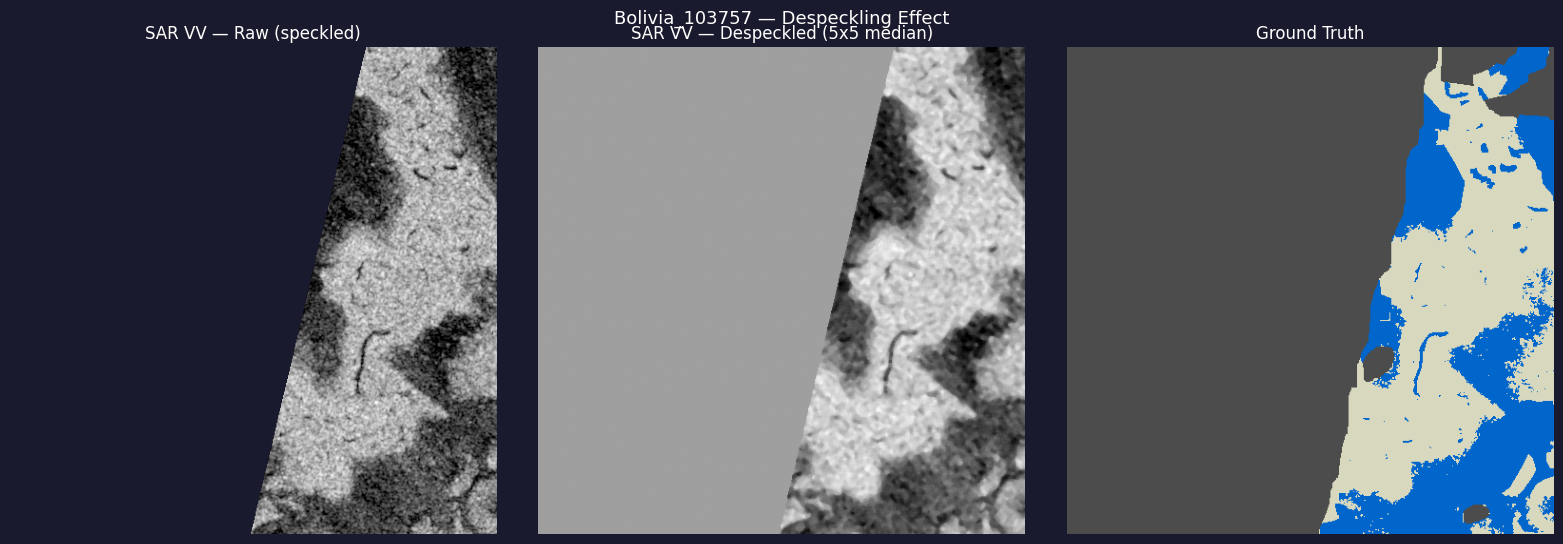

Saved: sar_despeckling.png


In [38]:
# ============================================================
# CELL 33 — SAR visualization: raw vs despeckled vs ground truth
# ============================================================
base_name = test_chips[0]
with rasterio.open(os.path.join(s1_dir, base_name + "_S1Hand.tif")) as src:
    vv_raw = src.read(1).astype(np.float32)
with rasterio.open(os.path.join(label_dir, base_name + "_LabelHand.tif")) as lsrc:
    label_viz = lsrc.read(1)

vv_filled = np.where(np.isnan(vv_raw), np.nanmedian(vv_raw), vv_raw)
vv_desp = median_filter(vv_filled, size=5)

label_display = np.zeros((*label_viz.shape, 3), dtype=np.float32)
label_display[label_viz == 0] = [0.85, 0.85, 0.75]
label_display[label_viz == 1] = [0.0, 0.4, 0.8]
label_display[label_viz == -1] = [0.3, 0.3, 0.3]

fig, axes = plt.subplots(1, 3, figsize=(16, 5.5))
fig.patch.set_facecolor('#1a1a2e')
axes[0].imshow(np.clip(vv_raw, -25, 0), cmap='gray')
axes[0].set_title("SAR VV — Raw (speckled)", color='white')
axes[1].imshow(np.clip(vv_desp, -25, 0), cmap='gray')
axes[1].set_title("SAR VV — Despeckled (5x5 median)", color='white')
axes[2].imshow(label_display)
axes[2].set_title("Ground Truth", color='white')
for ax in axes:
    ax.axis('off'); ax.set_facecolor('#1a1a2e')
plt.suptitle(f"{base_name} — Despeckling Effect", color='white', fontsize=13)
plt.tight_layout()
plt.savefig("/kaggle/working/sar_despeckling.png", dpi=150, bbox_inches='tight', facecolor='#1a1a2e')
plt.show()
print("Saved: sar_despeckling.png")

In [39]:
# ============================================================
# CELL 33b — Diagnose the despeckled visualization
# ============================================================
print("Raw VV stats:       min={:.2f}, max={:.2f}, mean={:.2f}, std={:.2f}".format(
    np.nanmin(vv_raw), np.nanmax(vv_raw), np.nanmean(vv_raw), np.nanstd(vv_raw)))
print("Despeckled stats:   min={:.2f}, max={:.2f}, mean={:.2f}, std={:.2f}".format(
    vv_desp.min(), vv_desp.max(), vv_desp.mean(), vv_desp.std())
)

Raw VV stats:       min=-40.82, max=-0.69, mean=-13.01, std=5.58
Despeckled stats:   min=-26.75, max=-3.76, mean=-12.19, std=3.27


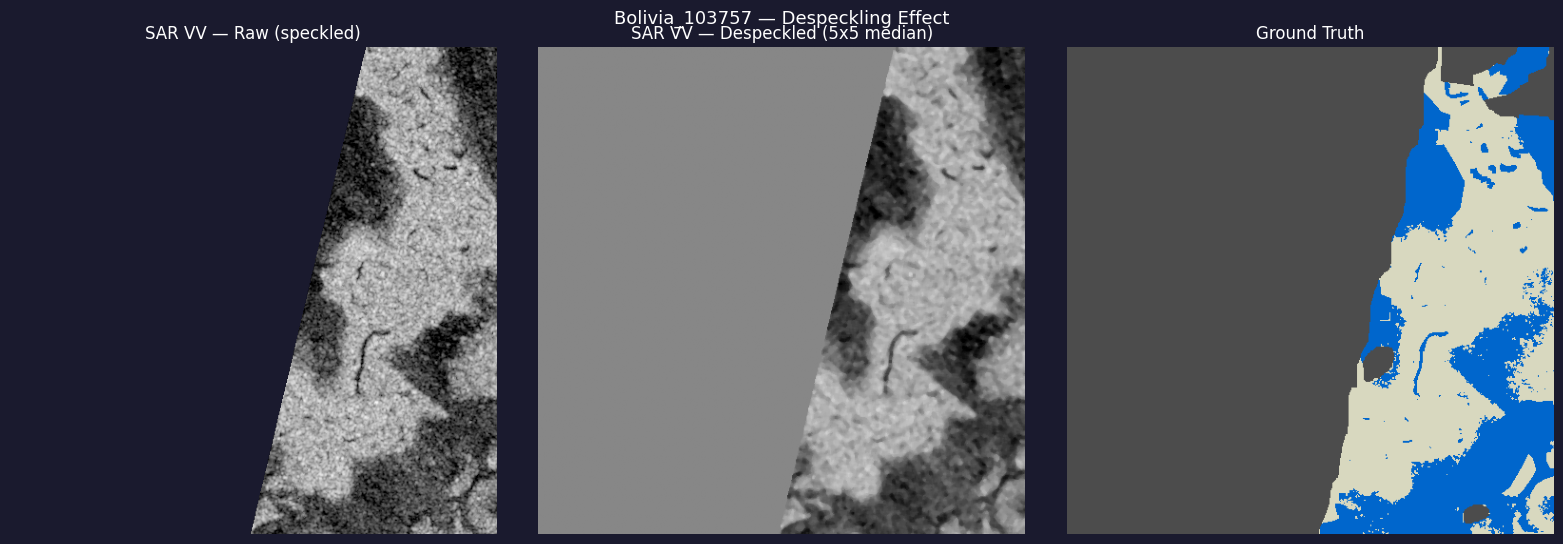

Saved: sar_despeckling.png


In [40]:
# ============================================================
# CELL 33c — Corrected visualization with FIXED, matching contrast scale
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 5.5))
fig.patch.set_facecolor('#1a1a2e')

axes[0].imshow(vv_raw, cmap='gray', vmin=-25, vmax=0)
axes[0].set_title("SAR VV — Raw (speckled)", color='white')
axes[1].imshow(vv_desp, cmap='gray', vmin=-25, vmax=0)
axes[1].set_title("SAR VV — Despeckled (5x5 median)", color='white')
axes[2].imshow(label_display)
axes[2].set_title("Ground Truth", color='white')
for ax in axes:
    ax.axis('off'); ax.set_facecolor('#1a1a2e')
plt.suptitle(f"{base_name} — Despeckling Effect", color='white', fontsize=13)
plt.tight_layout()
plt.savefig("/kaggle/working/sar_despeckling.png", dpi=150, bbox_inches='tight', facecolor='#1a1a2e')
plt.show()
print("Saved: sar_despeckling.png")

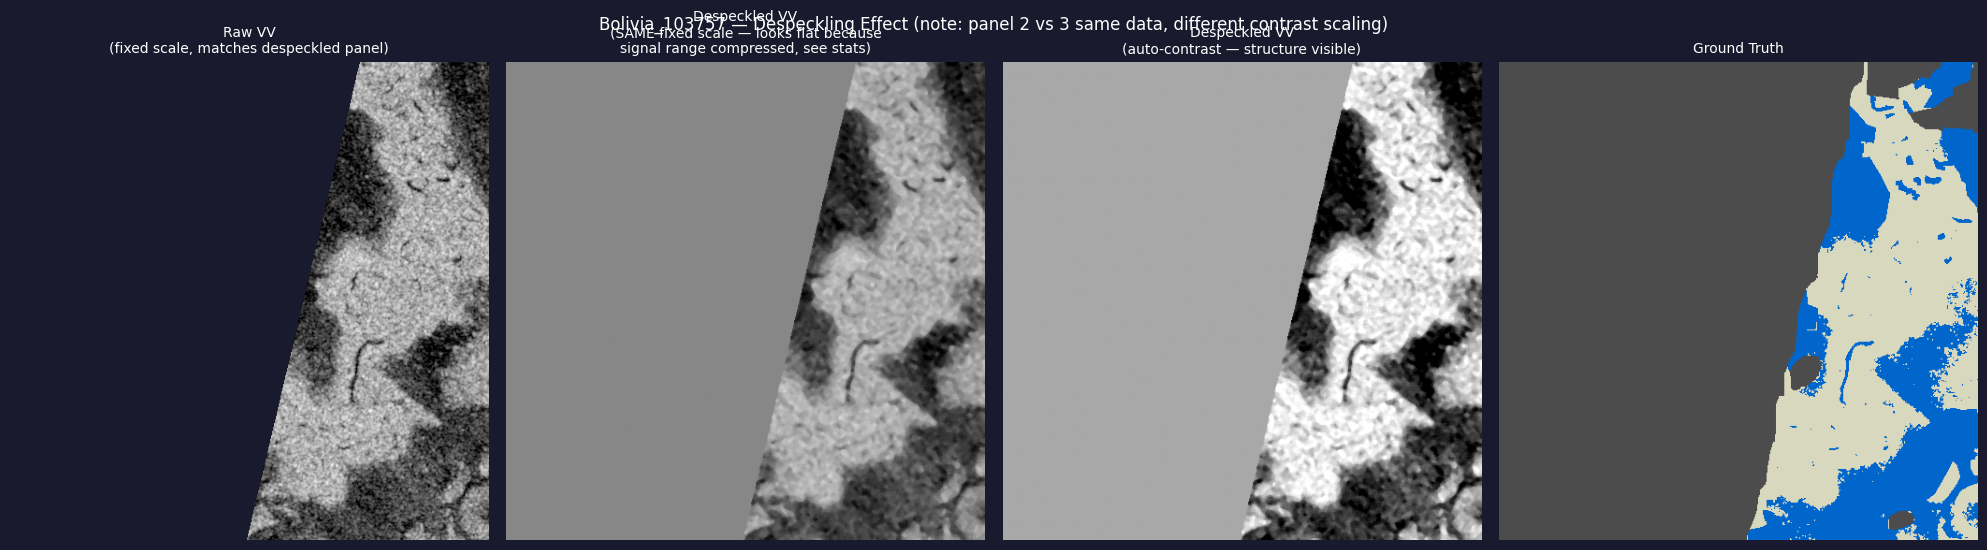

Saved: sar_despeckling.png


In [41]:
# ============================================================
# CELL 33d — Corrected visualization: fixed scale (for fair comparison)
# AND auto-scale (to actually see despeckled structure)
# ============================================================
fig, axes = plt.subplots(1, 4, figsize=(20, 5.5))
fig.patch.set_facecolor('#1a1a2e')

axes[0].imshow(vv_raw, cmap='gray', vmin=-25, vmax=0)
axes[0].set_title("Raw VV\n(fixed scale, matches despeckled panel)", color='white', fontsize=10)

axes[1].imshow(vv_desp, cmap='gray', vmin=-25, vmax=0)
axes[1].set_title("Despeckled VV\n(SAME fixed scale \u2014 looks flat because\nsignal range compressed, see stats)", color='white', fontsize=10)

axes[2].imshow(vv_desp, cmap='gray', vmin=np.percentile(vv_desp, 2), vmax=np.percentile(vv_desp, 98))
axes[2].set_title("Despeckled VV\n(auto-contrast \u2014 structure visible)", color='white', fontsize=10)

axes[3].imshow(label_display)
axes[3].set_title("Ground Truth", color='white', fontsize=10)

for ax in axes:
    ax.axis('off'); ax.set_facecolor('#1a1a2e')
plt.suptitle(f"{base_name} \u2014 Despeckling Effect (note: panel 2 vs 3 same data, different contrast scaling)", color='white', fontsize=12)
plt.tight_layout()
plt.savefig("/kaggle/working/sar_despeckling.png", dpi=150, bbox_inches='tight', facecolor='#1a1a2e')
plt.show()
print("Saved: sar_despeckling.png")